In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [2]:
!kaggle datasets download -d aymeneinformatique/cic-diad2024


Dataset URL: https://www.kaggle.com/datasets/aymeneinformatique/cic-diad2024
License(s): unknown
 98% 1.37G/1.39G [00:15<00:00, 63.5MB/s]
100% 1.39G/1.39G [00:15<00:00, 94.0MB/s]


In [3]:
import zipfile

zip_path = "cic-diad2024.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("cic_diad_2024")


In [4]:
import os

for root, dirs, files in os.walk("/content/cic_diad_2024"):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))


/content/cic_diad_2024/IoT device identification and anomaly detection dataset (CIC IoT-DIAD 2024)/Web-Based/Sqlinjection/SqlInjection.pcap_Flow.csv
/content/cic_diad_2024/IoT device identification and anomaly detection dataset (CIC IoT-DIAD 2024)/Web-Based/XSS/XSS.pcap_Flow.csv
/content/cic_diad_2024/IoT device identification and anomaly detection dataset (CIC IoT-DIAD 2024)/Web-Based/Uploading Attack/Uploading_Attack.pcap_Flow.csv
/content/cic_diad_2024/IoT device identification and anomaly detection dataset (CIC IoT-DIAD 2024)/DDOS/DDOS HTTP FLOOD/DDoS-HTTP_Flood-.pcap_Flow.csv
/content/cic_diad_2024/IoT device identification and anomaly detection dataset (CIC IoT-DIAD 2024)/DDOS/DDOS ICMP Fragmentation/DDoS-ICMP_Fragmentation12.pcap_Flow.csv
/content/cic_diad_2024/IoT device identification and anomaly detection dataset (CIC IoT-DIAD 2024)/DDOS/DDOS ICMP Fragmentation/DDoS-ICMP_Fragmentation19.pcap_Flow.csv
/content/cic_diad_2024/IoT device identification and anomaly detection datas

In [5]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from scipy.stats import ttest_rel


In [8]:
import os
os.listdir()


['.config', 'kaggle.json', 'cic_diad_2024', 'cic-diad2024.zip', 'sample_data']

In [10]:
import pandas as pd

df = pd.read_csv("/content/cic_diad_2024/IoT/Benign/BenignTraffic.pcap_Flow.csv")  # change filename
print(df.shape)
print(df.columns)
df.head()


(183630, 84)
Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std'

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.137.41-157.249.81.141-51746-80-6,192.168.137.41,51746,157.249.81.141,80,6,07/10/2022 02:15:01 PM,291959,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NeedManualLabel
1,192.168.137.41-157.249.81.141-50096-443-6,192.168.137.41,50096,157.249.81.141,443,6,07/10/2022 02:15:01 PM,291320,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NeedManualLabel
2,192.168.137.41-157.249.81.141-51749-80-6,192.168.137.41,51749,157.249.81.141,80,6,07/10/2022 02:15:03 PM,292739,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NeedManualLabel
3,192.168.137.41-157.249.81.141-50099-443-6,192.168.137.41,50099,157.249.81.141,443,6,07/10/2022 02:15:03 PM,292398,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NeedManualLabel
4,192.168.137.41-157.249.81.141-51752-80-6,192.168.137.41,51752,157.249.81.141,80,6,07/10/2022 02:15:04 PM,293252,5,4,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NeedManualLabel


In [11]:
for col in df.columns:
    if "label" in col.lower() or "attack" in col.lower() or "class" in col.lower():
        print("Possible label column:", col)


Possible label column: Label


In [12]:
import os
import pandas as pd
import numpy as np
import gc
import time
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [13]:
base_path = "/content/cic_diad_2024/IoT"  # change if needed

dataframes = []

attack_folders = os.listdir(base_path)
print("Available Attack Types:", attack_folders)


Available Attack Types: ['Web-Based', 'DDOS', 'Spoofing', 'Brute Force', 'Recon', 'DOS', 'Mirai', 'Benign']


In [15]:
selected_attacks = attack_folders[:20]  # first 20 folders
print("Using these attacks:", selected_attacks)


Using these attacks: ['Web-Based', 'DDOS', 'Spoofing', 'Brute Force', 'Recon', 'DOS', 'Mirai', 'Benign']


In [16]:
for attack in tqdm(selected_attacks):
    folder_path = os.path.join(base_path, attack)

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):

            file_path = os.path.join(folder_path, file)

            try:
                temp_df = pd.read_csv(file_path)

                # Create label
                if attack.lower() == "benign":
                    temp_df["Label"] = 0
                else:
                    temp_df["Label"] = 1

                dataframes.append(temp_df)

            except:
                continue

df = pd.concat(dataframes, ignore_index=True)

del dataframes
gc.collect()

print("Final Shape:", df.shape)


100%|██████████| 8/8 [00:14<00:00,  1.81s/it]


Final Shape: (1018695, 84)


In [17]:
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = df[col].astype('float32')
    elif df[col].dtype == 'int64':
        df[col] = df[col].astype('int32')


In [18]:
non_numeric = df.select_dtypes(exclude=[np.number]).columns
df.drop(columns=non_numeric, inplace=True)


In [19]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)


In [20]:
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

del df
gc.collect()


0

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

del X_train, X_test
gc.collect()


0

In [22]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X_train_scaled.shape[1])
print("Reduced Features:", X_train_pca.shape[1])


Original Features: 79
Reduced Features: 31


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

}


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)



Training Logistic Regression
Accuracy: 0.6470
Precision: 0.6581
Recall: 0.8748
F1 Score: 0.7511
ROC-AUC: 0.6772
PR-AUC: 0.7669
False Positive Rate: 0.7079
Training Time: 34.45 sec

Threshold Analysis (FPR)
Threshold 0.5 → FPR: 0.7079
Threshold 0.6 → FPR: 0.3483
Threshold 0.7 → FPR: 0.0846
Threshold 0.8 → FPR: 0.0296


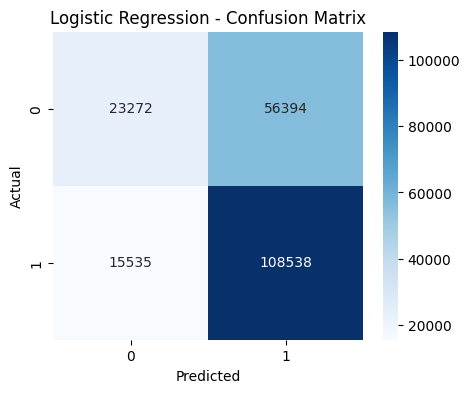

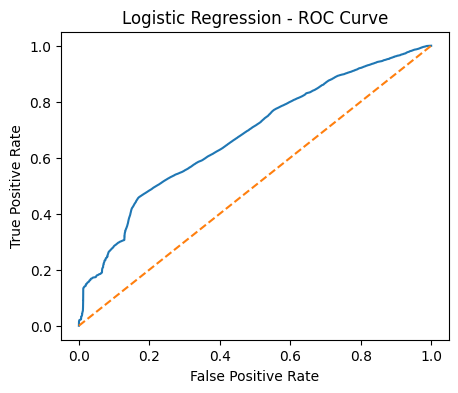

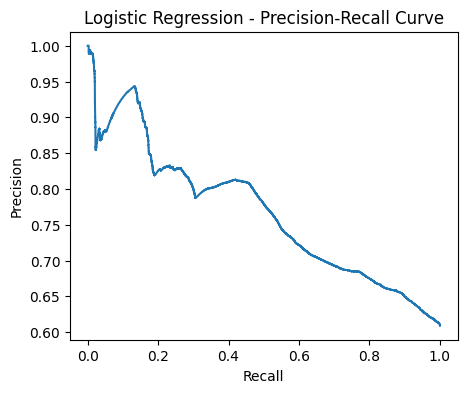


Training Random Forest
Accuracy: 0.7979
Precision: 0.9285
Recall: 0.7239
F1 Score: 0.8135
ROC-AUC: 0.9067
PR-AUC: 0.9446
False Positive Rate: 0.0868
Training Time: 446.58 sec

Threshold Analysis (FPR)
Threshold 0.5 → FPR: 0.0868
Threshold 0.6 → FPR: 0.0494
Threshold 0.7 → FPR: 0.0244
Threshold 0.8 → FPR: 0.0051


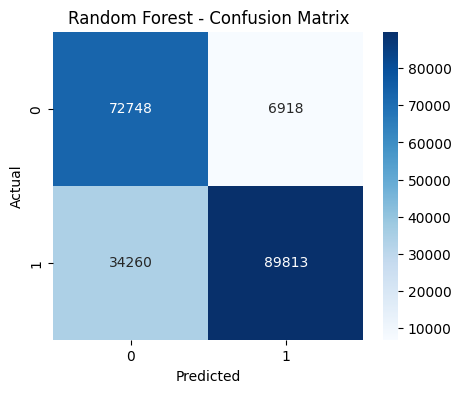

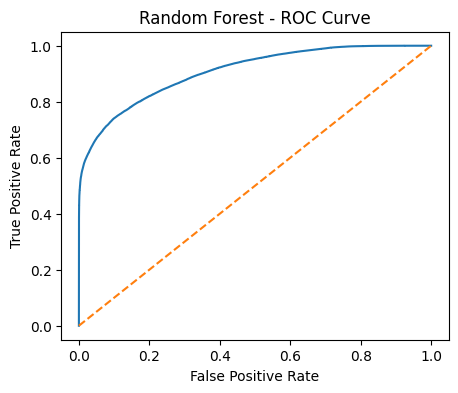

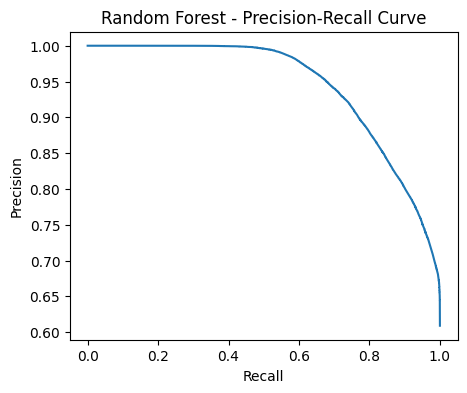

In [29]:
results = []

for name, model in models.items():

    print("\n" + "="*50)
    print(f"Training {name}")
    print("="*50)

    start = time.time()
    model.fit(X_train_pca, y_train)
    train_time = time.time() - start

    # Predictions
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc,
        "PR-AUC": pr_auc,
        "FPR": fpr,
        "Train Time (s)": train_time
    })

    # Print metrics
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"False Positive Rate: {fpr:.4f}")
    print(f"Training Time: {train_time:.2f} sec")

    # 🔥 Threshold Analysis
    print("\nThreshold Analysis (FPR)")
    for t in [0.5, 0.6, 0.7, 0.8]:
        y_temp = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_temp).ravel()
        temp_fpr = fp / (fp + tn)
        print(f"Threshold {t} → FPR: {temp_fpr:.4f}")

    # 📊 Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 📈 ROC Curve
    fpr_vals, tpr_vals, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(5,4))
    plt.plot(fpr_vals, tpr_vals)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # 📈 Precision-Recall Curve
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(5,4))
    plt.plot(rec_vals, prec_vals)
    plt.title(f"{name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()


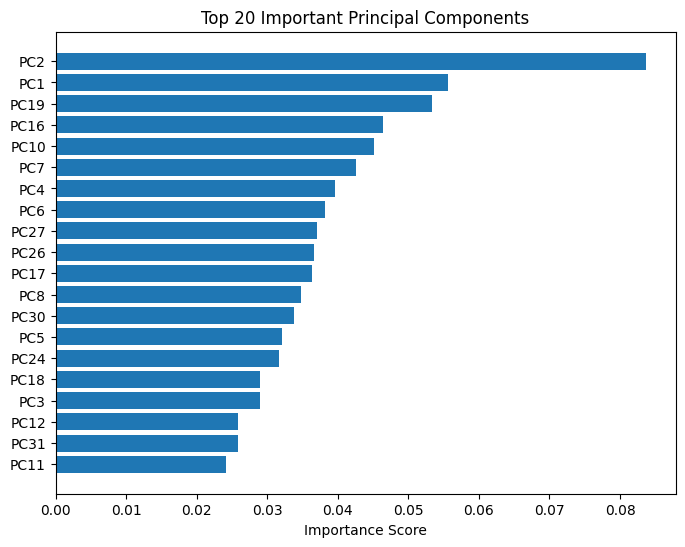

In [35]:
# Use best model (Random Forest)
best_model = models["Random Forest"]
best_model.fit(X_train_pca, y_train)

import numpy as np
import matplotlib.pyplot as plt

importances = best_model.feature_importances_

# Since PCA used
feature_names = [f"PC{i+1}" for i in range(len(importances))]

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Importance Score")
plt.title("Top 20 Important Principal Components")
plt.show()



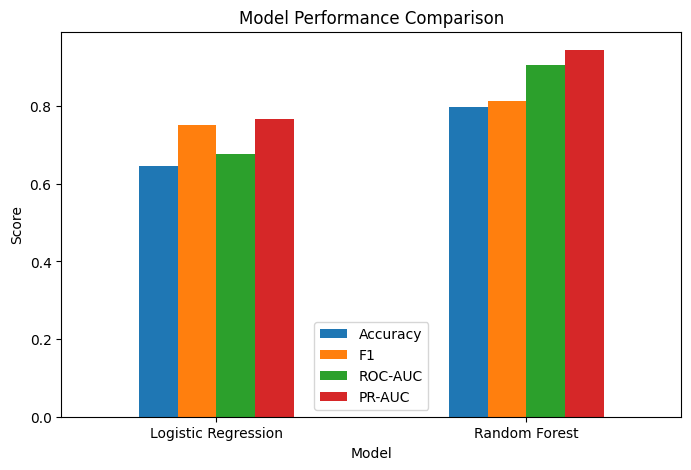

In [31]:
results_df.set_index("Model")[["Accuracy","F1","ROC-AUC","PR-AUC"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


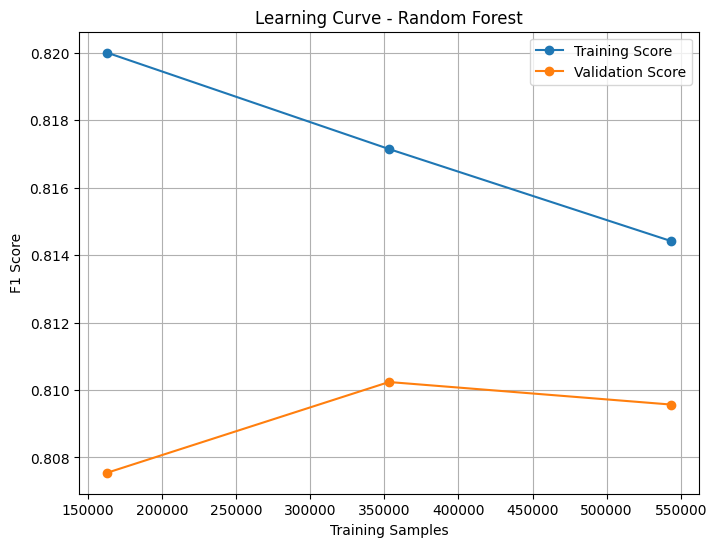

In [38]:
from sklearn.model_selection import learning_curve

fast_rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    fast_rf,
    X_train_pca,
    y_train,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.3, 1.0, 3)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Score")
plt.xlabel("Training Samples")
plt.ylabel("F1 Score")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()


In [39]:
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix

def find_optimal_threshold(y_true, y_prob, fpr_limit=0.05):

    thresholds = np.linspace(0.1, 0.9, 50)
    best_threshold = 0.5
    best_f1 = 0

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        fpr = fp / (fp + tn)

        if fpr <= fpr_limit:
            f1 = f1_score(y_true, y_pred)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = t

    return best_threshold, best_f1


In [40]:
# Get probabilities
y_prob_rf = best_model.predict_proba(X_test_pca)[:,1]

# Find optimal threshold
optimal_t, optimal_f1 = find_optimal_threshold(
    y_test, y_prob_rf, fpr_limit=0.05
)

print("Optimal Threshold:", optimal_t)
print("Best F1 under FPR constraint:", optimal_f1)


Optimal Threshold: 0.6061224489795919
Best F1 under FPR constraint: 0.7839228479309132


In [41]:
y_pred_atrf = (y_prob_rf >= optimal_t).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_atrf).ravel()
fpr_atrf = fp / (fp + tn)

print("\nATRF Results")
print("F1:", f1_score(y_test, y_pred_atrf))
print("FPR:", fpr_atrf)



ATRF Results
F1: 0.7839228479309132
FPR: 0.04756106745663144
